# Does gradient conflict predict the effect of lexicographic training?

This notebook analyses the completed coarse-first lexicographic runs on four substrates: H-CAST, Hier-COS (global and level softmax), HRN under the level-conditional objective, and HT-CapsNet. It keeps two questions separate:

1. **Predictive question.** Does the baseline cosine predict the paired lex-minus-baseline performance change? This is the correct comparison for deciding whether conflict present before the intervention predicts benefit.
2. **Mechanism question.** What does projection do to the gradient geometry over training? The per-epoch trajectories show how much conflict the operator removes at each step, that the post-projection cosine is zero as intended, and how far the lex run's geometry drifts away from its paired baseline. This describes the intervention, but it has no baseline counterfactual for performance and cannot by itself establish that projection improved the trained model.

Both coarse-first projection stages are analysed: middle versus coarse, and fine versus the assembled higher-priority direction. The primary response is TICE; FPA, fine accuracy, and AHD are secondary. One decoder and one readout are chosen at the top of the notebook and applied to every metric in both arms, always from the checkpoint selected for that decoder, under the same contract as the trade-off notebooks. Under top-down decoding TICE is dropped rather than reported, because a top-down path is consistent by construction and `tice_topdown` is identically zero. **TICE reduction is baseline TICE minus lex TICE, so a positive value means that lex lowered (improved) TICE.** FPA and accuracy changes are lex minus baseline, so positive also means better.

H-CAST remains in the analysis, paired against its global-KL baseline. That arm is not projection-only matched: lex mode also disables global KL, so the config audit labels every H-CAST cell a descriptive package effect and the performance change carries both edits. The within-lex pre/post mechanism check is unaffected, because it compares the gradient before and after the operator inside the lex run itself.

Coverage is not uniform. HRN is paired against its level-conditional control, which is the objective the lex arm projects, and HT-CapsNet against its own baseline. Where a lex run has not finished on a dataset, that cell is reported as missing in the audit and dropped from every table and figure rather than substituted. Cells resolved on a single paired seed state one paired difference and carry no seed spread; the audit and the main table both print the seed count so this stays visible.

The default cosine window is epochs 81--100, already specified in the thesis analysis notes. Window sensitivity is shown explicitly. Model–dataset cell means, rather than individual seeds treated as independent observations, are used for the signed joint margin.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEARCH_PATHS = [
    Path.cwd(),
    *(parent / 'notebooks' / 'utils' for parent in (Path.cwd(), *Path.cwd().parents)),
]
HELPER_DIR = next(
    (path for path in SEARCH_PATHS if (path / 'lex_conflict_analysis_utils.py').is_file()),
    None,
)
if HELPER_DIR is None:
    raise FileNotFoundError('Run this notebook from the repository tree so notebooks/utils is discoverable.')
sys.path.insert(0, str(HELPER_DIR))

from lex_conflict_analysis_utils import (
    DECODERS,
    READOUTS,
    SUBSTRATE_STYLES,
    collect_analysis,
    cosine_trajectories,
    joint_response_labels,
    performance_specs,
    run_roots_table,
    run_specs,
    substrate_order,
    summarize_cells,
    window_joint_margins,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
EPOCH_WINDOW = (81, 100)
TRAJECTORY_RANGE = (1, 100)

# One decoder and one readout are applied to every performance metric in both
# arms, under the same contract as the trade-off notebooks.
DECODER = 'independent'
READOUT = 'subspace_norm'
SUBSPACE_SCORE_SPACE = 'probability'

# ---- what to compare -------------------------------------------------------
# dataset -> substrate -> (baseline, lex), the same shape the inference-analysis
# notebooks use for RUN_ROOTS. Comment a line out to drop that cell; a baseline
# may also be a list of candidates, and the first one with completed seeds wins.
# Every other field of a cell is derived, so this mapping is the whole selection.
RUN_ROOTS = {
    'cifar100': {
        'H-CAST': ('hcast_cifar100',
                   'hcast_cifar100_lex_coarse_first'),
        'Hier-COS global': ('hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf',
                            'hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first_kl_leaf'),
        'Hier-COS level': ('hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_block',
                           'hiercos_cifar100_level_softmax_ce_reg_lex_coarse_first_kl_leaf_block'),
        # HRN is paired against the level-conditional control, the objective the
        # lex arm actually projects. The plain HRN runs differ in batch size too.
        'HRN': ('hrn_cifar100_level_conditional',
                'hrn_cifar100_level_conditional_lex_coarse_first'),
        'HT-CapsNet': ('capsnet_cifar100', '')
                       #'ht_capsnet_cifar100_lex_coarse_first'),
    },
    'cub200': {
        'H-CAST': ('hcast_cub200',
                   'hcast_cub200_lex_coarse_first'),
        'Hier-COS global': ('hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf',
                            'hiercos_cub200_global_softmax_ce_reg_lex_coarse_first_kl_leaf'),
        'Hier-COS level': ('hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf_identity',
                           'hiercos_cub200_level_softmax_ce_reg_lex_coarse_first_kl_leaf_identity'),
        'HRN': ('hrn_cub200_level_conditional',
                'hrn_cub200_level_conditional_lex_coarse_first'),
        'HT-CapsNet': ('capsnet_cub200',
                       'ht_capsnet_cub200_lex_coarse_first'),
    },
    'aircraft': {
        'H-CAST': ('hcast_aircraft',
                   'hcast_aircraft_lex_coarse_first'),
        'Hier-COS global': ('hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf',
                            'hiercos_aircraft_global_softmax_ce_reg_lex_coarse_first_kl_leaf'),
        'Hier-COS level': ('hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf_identity',
                           'hiercos_aircraft_level_softmax_ce_reg_lex_coarse_first_kl_leaf_identity'),
        'HRN': ('hrn_aircraft_level_conditional',
                'hrn_aircraft_level_conditional_lex_coarse_first'),
        'HT-CapsNet': ('capsnet_aircraft',
                       'ht_capsnet_aircraft_lex_coarse_first'),
    },
}
# The fine-first arms are a separate substrate rather than a second order, so
# each keeps its own series in every figure:
#   RUN_ROOTS['cifar100']['H-CAST fine-first'] = (
#       'hcast_cifar100', 'hcast_cifar100_lex_fine_first')

RUN_SPECS = run_specs(RUN_ROOTS)
# One ordering for every table and figure: substrates in their canonical order,
# datasets in the order used by the trade-off notebooks.
SUBSTRATE_RANK = {substrate: rank for rank, substrate in enumerate(substrate_order())}
DATASET_RANK = {'CIFAR-100': 0, 'CUB-200': 1, 'Aircraft': 2}

def ordered_by_cell(frame):
    ranked = frame.assign(
        _substrate_rank=frame['substrate'].map(SUBSTRATE_RANK),
        _dataset_rank=frame['dataset'].map(DATASET_RANK),
    )
    return (
        ranked.sort_values(['_substrate_rank', '_dataset_rank'])
        .drop(columns=['_substrate_rank', '_dataset_rank'])
    )
PERFORMANCE_LABELS = list(performance_specs(DECODER))
JOINT_RESPONSES = joint_response_labels(DECODER)

view_note = f'Decoder: {DECODER} | readout: {READOUT}'
if READOUT == 'subspace_norm':
    view_note += f' | subspace score space: {SUBSPACE_SCORE_SPACE}'
print(view_note)
print(f'Available decoders: {DECODERS} | available readouts: {READOUTS}')
if READOUT == 'native':
    print('Native inference is family-specific: node_score for H-CAST, subspace_norm for Hier-COS, and '
          'each of HRN and HT-CapsNet under its own head.')
if DECODER == 'topdown':
    print('TICE is excluded under top-down decoding: the predicted path is consistent by '
          'construction, so tice_topdown is identically zero.')
if READOUT == 'subspace_norm':
    print('The subspace-norm readout is close to hierarchically consistent on its own, so TICE '
          'is small for every run under it and TICE-based margins collapse towards zero.')


Decoder: independent | readout: subspace_norm | subspace score space: probability
Available decoders: ('independent', 'topdown') | available readouts: ('native', 'node_score', 'subspace_norm')
The subspace-norm readout is close to hierarchically consistent on its own, so TICE is small for every run under it and TICE-based margins collapse towards zero.


## Run resolution and comparability audit

The table below is part of the result, not bookkeeping. A projection-only matched comparison differs only through the lexicographic mechanism fields. A descriptive lex package comparison contains at least one additional training change. In the current H-CAST outputs that additional change is global KL: the native baseline has it enabled and the lex arm has it disabled. The audit also records the decoder and readout in force, so a table lifted out of the notebook still states which view produced it. The runs themselves are chosen in the setup cell: `RUN_ROOTS` maps dataset to substrate to a `(baseline, lex)` pair, and the table above it lists every configured pair with its seed counts, so a mistyped or unfinished selection shows up there rather than silently vanishing. It is also the coverage record: the `n` column is the number of paired seeds actually available in each cell, and a cell whose scope reads `missing completed paired seeds` has no finished lex run to pair against and is therefore absent from every table and figure below.

In [2]:
# Every configured pair and its seed coverage, including selections that do not
# exist yet, so a mistyped or unfinished run is visible rather than just absent.
display(run_roots_table(OUTPUTS_ROOT, RUN_ROOTS))

seed_df, cosine_df, audit_df = collect_analysis(
    OUTPUTS_ROOT,
    RUN_SPECS,
    epoch_window=EPOCH_WINDOW,
    decoder=DECODER,
    readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)
if seed_df.empty or cosine_df.empty:
    raise RuntimeError('No completed paired baseline / lex runs were found.')

audit_columns = [
    'substrate', 'dataset', 'n', 'decoder', 'readout', 'config_matched',
    'comparison_scope', 'baseline_global_kl', 'lex_global_kl',
]
display(ordered_by_cell(audit_df)[audit_columns].reset_index(drop=True))

logged_epoch_check = cosine_df[[
    'cell_id', 'seed', 'stage', 'baseline_logged_epochs',
    'lex_pre_logged_epochs', 'lex_post_logged_epochs',
]].copy()
expected_epochs = EPOCH_WINDOW[1] - EPOCH_WINDOW[0] + 1
incomplete = logged_epoch_check[
    (logged_epoch_check['baseline_logged_epochs'] != expected_epochs)
    | (logged_epoch_check['lex_pre_logged_epochs'] != expected_epochs)
    | (logged_epoch_check['lex_post_logged_epochs'] != expected_epochs)
]
print(f'Paired seed comparisons: {len(seed_df)}')
print(f'Expected logged epochs per seed and cosine: {expected_epochs}')
print('Incomplete cosine windows:', len(incomplete))
if not incomplete.empty:
    display(incomplete)


,substrate,dataset,baseline_run,baseline_seeds,lex_run,lex_seeds,paired_seeds
0,H-CAST,CIFAR-100,hcast_cifar100,3,hcast_cifar100_lex_coarse_first,3,3
1,Hier-COS global,CIFAR-100,hiercos_cifar100_global_softmax_ce_reg_baselin...,3,hiercos_cifar100_global_softmax_ce_reg_lex_coa...,3,3
2,Hier-COS level,CIFAR-100,hiercos_cifar100_level_softmax_ce_reg_baseline...,3,hiercos_cifar100_level_softmax_ce_reg_lex_coar...,3,3
3,HRN,CIFAR-100,hrn_cifar100_level_conditional,3,hrn_cifar100_level_conditional_lex_coarse_first,3,3
4,HT-CapsNet,CIFAR-100,capsnet_cifar100,3,,0,0
5,H-CAST,CUB-200,hcast_cub200,3,hcast_cub200_lex_coarse_first,3,3
6,Hier-COS global,CUB-200,hiercos_cub200_global_softmax_ce_reg_baseline_...,3,hiercos_cub200_global_softmax_ce_reg_lex_coars...,3,3
7,Hier-COS level,CUB-200,hiercos_cub200_level_softmax_ce_reg_baseline_k...,3,hiercos_cub200_level_softmax_ce_reg_lex_coarse...,3,3
8,HRN,CUB-200,hrn_cub200_level_conditional,3,hrn_cub200_level_conditional_lex_coarse_first,3,3
9,HT-CapsNet,CUB-200,capsnet_cub200,3,ht_capsnet_cub200_lex_coarse_first,3,3


,substrate,dataset,n,decoder,readout,config_matched,comparison_scope,baseline_global_kl,lex_global_kl
0,H-CAST,CIFAR-100,3,independent,subspace_norm,False,descriptive lex package; inspect config differ...,True,False
1,H-CAST,CUB-200,3,independent,subspace_norm,False,descriptive lex package; inspect config differ...,True,False
2,H-CAST,Aircraft,3,independent,subspace_norm,False,descriptive lex package; inspect config differ...,True,False
3,Hier-COS global,CIFAR-100,3,independent,subspace_norm,True,projection-only matched comparison,None,None
4,Hier-COS global,CUB-200,3,independent,subspace_norm,True,projection-only matched comparison,None,None
5,Hier-COS global,Aircraft,3,independent,subspace_norm,True,projection-only matched comparison,None,None
6,Hier-COS level,CIFAR-100,3,independent,subspace_norm,True,projection-only matched comparison,None,None
7,Hier-COS level,CUB-200,3,independent,subspace_norm,True,projection-only matched comparison,None,None
8,Hier-COS level,Aircraft,3,independent,subspace_norm,True,projection-only matched comparison,None,None
9,HRN,CIFAR-100,3,independent,subspace_norm,True,projection-only matched comparison,None,None


Paired seed comparisons: 42
Expected logged epochs per seed and cosine: 20
Incomplete cosine windows: 0


## Cell-level data

Cosines are epoch means averaged within each seed and then across paired seeds. Performance changes are also paired per seed before aggregation. Yellow cosine cells mark conflict (cosine < 0); green performance cells mean lex is better and red cells mean lex is worse. For TICE, green therefore means a reduction. This compact table shows the cell means; seed-level values and sample standard deviations remain available in `seed_df` and `cell_df`.

In [3]:
cell_df = summarize_cells(seed_df, cosine_df)

cell_keys = ['cell_id', 'family', 'substrate', 'dataset', 'config_matched']
cosines = cell_df.pivot(
    index=cell_keys,
    columns='stage',
    values=['baseline_pre_cos__mean'],
).reset_index()
cosines.columns = [
    column if isinstance(column, str) else ' '.join(part for part in column if part)
    for column in cosines.columns
]

table_labels = [label for label in PERFORMANCE_LABELS if label != 'AHD gain']
# Paired-seed count per cell, carried into the table because coverage is uneven:
# a one-seed cell states a single paired difference, not a seed mean.
seed_count_column = f'{table_labels[0]}__count'
performance = cell_df[cell_df['stage'] == 'fine / higher'][[
    *cell_keys, seed_count_column, *(f'{label}__mean' for label in table_labels)
]].copy()
main_table = performance.merge(cosines, on=cell_keys, validate='one_to_one').rename(columns={
    'baseline_pre_cos__mean mid / coarse': 'baseline cos: mid/coarse',
    'baseline_pre_cos__mean fine / higher': 'baseline cos: fine/higher',
    seed_count_column: 'seeds',
    **{f'{label}__mean': label for label in table_labels},
})
main_table = ordered_by_cell(main_table)
main_table['comparison'] = main_table['config_matched'].map({
    True: 'projection-only',
    False: 'package effect',
})
cosine_columns = ['baseline cos: mid/coarse', 'baseline cos: fine/higher']
gain_columns = table_labels
main_view = main_table.rename(columns={'substrate': 'model'})[[
    'model', 'dataset', 'comparison', 'seeds', *cosine_columns, *gain_columns,
]]

def shade_conflict(value):
    return 'background-color: #fff2cc' if value < 0 else ''

def shade_gain(value):
    if value > 0:
        return 'background-color: #e2f0d9'
    if value < 0:
        return 'background-color: #fce4d6'
    return ''

display(
    main_view.style
    .format(precision=3, subset=cosine_columns + gain_columns)
    .format('{:.0f}', subset=['seeds'])
    .map(shade_conflict, subset=cosine_columns)
    .map(shade_gain, subset=gain_columns)
    .hide(axis='index')
)

# Full seed-level values and standard deviations remain available in seed_df and cell_df.


model,dataset,comparison,seeds,baseline cos: mid/coarse,baseline cos: fine/higher,TICE reduction (pp),FPA gain (pp),fine-accuracy gain (pp)
H-CAST,CIFAR-100,package effect,3,0.760,0.650,0.013,0.170,0.147
H-CAST,CUB-200,package effect,3,0.502,0.372,-0.017,-0.201,-0.190
H-CAST,Aircraft,package effect,3,0.653,0.529,0.000,-0.830,-0.830
Hier-COS global,CIFAR-100,projection-only,3,0.161,-0.820,0.463,-0.203,-0.320
Hier-COS global,CUB-200,projection-only,3,0.109,-0.824,0.178,0.305,0.201
Hier-COS global,Aircraft,projection-only,3,0.077,-0.864,0.190,-0.130,-0.180
Hier-COS level,CIFAR-100,projection-only,3,0.381,0.335,-0.337,-1.150,-1.170
Hier-COS level,CUB-200,projection-only,3,0.085,0.089,0.029,0.282,0.288
Hier-COS level,Aircraft,projection-only,3,0.143,0.239,0.090,-1.080,-1.090
HRN,CIFAR-100,projection-only,3,0.298,0.220,-0.613,-0.670,-0.481


## Question 1: does baseline conflict predict lex benefit?

Each plot uses one of the two baseline cosines. Negative values indicate local first-order conflict; positive TICE reduction and positive FPA gain both indicate improvement.

The only hypothesis metric is the **signed joint margin** `J = -baseline cosine × performance improvement`. Positive values support the hypothesis, negative values contradict it, and magnitude measures how strongly both cosine and performance differ from zero. Its supporting quadrants are **upper-left** (conflict and lex improves) and **lower-right** (alignment and the metric deteriorates). Separate TICE and FPA figures shade these quadrants and report mean `J` for every substrate: H-CAST, Hier-COS global softmax, Hier-COS level softmax, HRN under the level-conditional objective, and HT-CapsNet. Substrates whose two arms are not projection-only matched are labelled package effect from the audit rather than by hand; in the current outputs that is H-CAST, where global KL also changes. The number of cells behind each mean differs by substrate, so the per-cell range is reported next to it. Cells resolved on a single paired seed are drawn with a hollow marker, because they state one paired difference rather than a seed mean; the vertical scale of the TICE figure is set by one such cell, HRN on CIFAR-100.

outcome,model,cosine,evaluated cells,mean J,min J,max J
TICE reduction,H-CAST,mid / coarse,3,-0.000,-0.010,+0.009
TICE reduction,H-CAST,fine / higher,3,-0.001,-0.009,+0.006
TICE reduction,Hier-COS global,mid / coarse,3,-0.036,-0.075,-0.015
TICE reduction,Hier-COS global,fine / higher,3,+0.230,+0.147,+0.380
TICE reduction,Hier-COS level,mid / coarse,3,+0.038,-0.013,+0.128
TICE reduction,Hier-COS level,fine / higher,3,+0.030,-0.021,+0.113
TICE reduction,HRN,mid / coarse,3,+0.060,-0.002,+0.183
TICE reduction,HRN,fine / higher,3,+0.045,-0.002,+0.135
TICE reduction,HT-CapsNet,mid / coarse,2,-1.415,-2.281,-0.548
TICE reduction,HT-CapsNet,fine / higher,2,-1.463,-2.453,-0.474


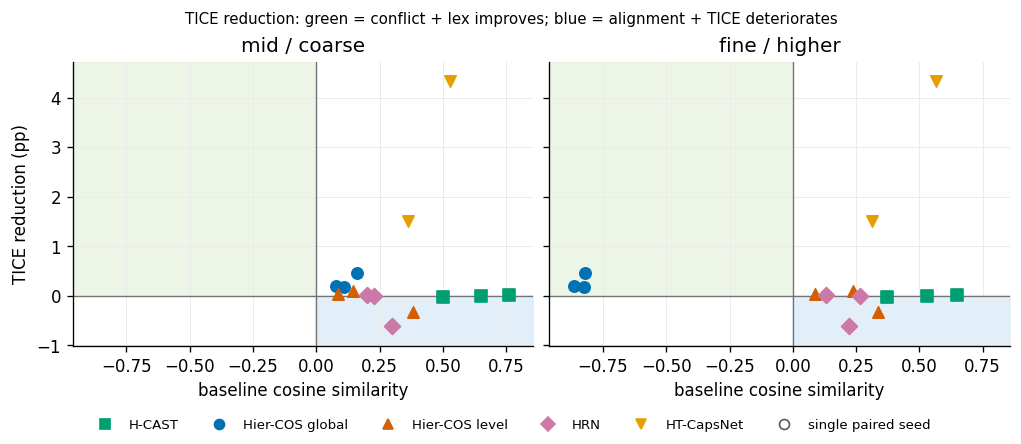

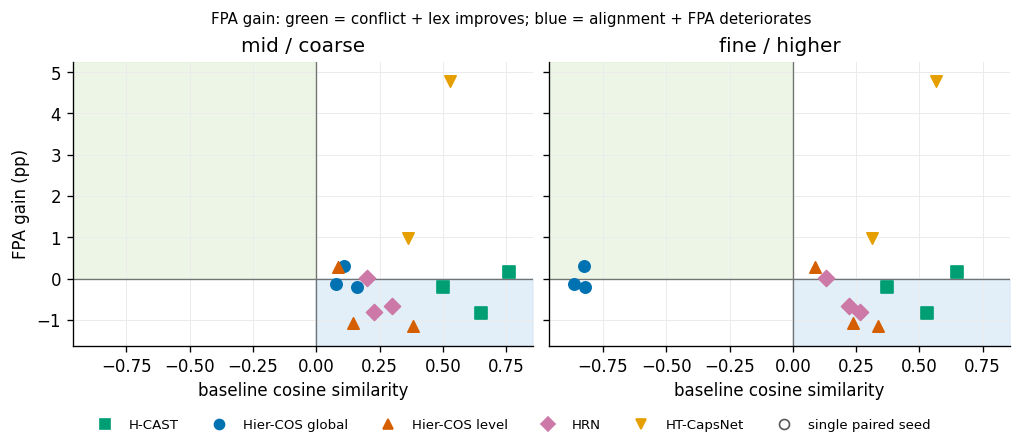

In [4]:
from matplotlib.lines import Line2D

outcome_labels = {
    'TICE reduction (pp)': 'TICE reduction',
    'FPA gain (pp)': 'FPA gain',
}
outcome_specs = {
    outcome_labels[label]: {
        'response': label,
        'column': f'{label}__mean',
        'axis': label,
        'deterioration': f'{outcome_labels[label].split()[0]} deteriorates',
    }
    for label in JOINT_RESPONSES
}
# Substrates are taken from the resolved cells, so a family with no completed
# paired run simply does not appear rather than producing an empty series.
group_order = substrate_order(cell_df)
# A substrate is labelled package effect from the audit, not by hand: it holds
# whenever any of its resolved cells is not projection-only matched.
package_substrates = set(cell_df.loc[~cell_df['config_matched'], 'substrate'])

def scope_suffix(substrate):
    return ' (package effect)' if substrate in package_substrates else ''

margin_rows = []
for outcome, outcome_spec in outcome_specs.items():
    for substrate in group_order:
        for stage in ['mid / coarse', 'fine / higher']:
            rows = cell_df[(cell_df['substrate'] == substrate) & (cell_df['stage'] == stage)]
            margins = (-rows['baseline_pre_cos__mean'] * rows[outcome_spec['column']]).dropna()
            margin_rows.append({
                'outcome': outcome,
                'model': substrate,
                'cosine': stage,
                'evaluated cells': int(margins.size),
                'mean J': margins.mean() if margins.size else np.nan,
                'min J': margins.min() if margins.size else np.nan,
                'max J': margins.max() if margins.size else np.nan,
            })
joint_check = pd.DataFrame(margin_rows)
margin_columns = ['mean J', 'min J', 'max J']

def shade_margin(value):
    if pd.isna(value):
        return ''
    if value > 0:
        return 'background-color: #e2f0d9'
    if value < 0:
        return 'background-color: #fce4d6'
    return ''

display(
    joint_check.style
    .format({column: '{:+.3f}' for column in margin_columns})
    .map(shade_margin, subset=['mean J'])
    .hide(axis='index')
)

model_style = {substrate: SUBSTRATE_STYLES[substrate] for substrate in group_order}
# Legend handles are built explicitly so a substrate whose only cells are
# single-seed still appears, and so the hollow convention is stated once.
model_handles = [
    Line2D([], [], linestyle='none', marker=style['marker'], color=style['color'], label=substrate)
    for substrate, style in model_style.items()
]
single_seed_handle = Line2D(
    [], [], linestyle='none', marker='o', markerfacecolor='none',
    markeredgecolor='0.35', label='single paired seed',
)
cosine_values = cell_df['baseline_pre_cos__mean']
cosine_padding = max((cosine_values.max() - cosine_values.min()) * 0.06, 0.05)
x_limits = (
    min(cosine_values.min(), 0.0) - cosine_padding,
    max(cosine_values.max(), 0.0) + cosine_padding,
)
for outcome, outcome_spec in outcome_specs.items():
    outcome_values = cell_df[outcome_spec['column']]
    raw_min, raw_max = min(outcome_values.min(), 0), max(outcome_values.max(), 0)
    padding = max((raw_max - raw_min) * 0.08, 0.05)
    y_limits = (raw_min - padding, raw_max + padding)
    figure, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), sharex=True, sharey=True, constrained_layout=True)
    for axis, stage in zip(axes, ['mid / coarse', 'fine / higher']):
        axis.fill_between([x_limits[0], 0], 0, y_limits[1], color='#e2f0d9', alpha=0.65)
        axis.fill_between([0, x_limits[1]], y_limits[0], 0, color='#d9eaf7', alpha=0.75)
        stage_rows = cell_df[cell_df['stage'] == stage]
        for substrate, style in model_style.items():
            rows = stage_rows[stage_rows['substrate'] == substrate]
            # Cells resolved on one paired seed are drawn hollow: they are a
            # single paired difference, not a seed mean.
            multi_seed = rows[rows[seed_count_column] > 1]
            single_seed = rows[rows[seed_count_column] == 1]
            axis.scatter(
                multi_seed['baseline_pre_cos__mean'], multi_seed[outcome_spec['column']],
                color=style['color'], marker=style['marker'], s=46, zorder=3,
            )
            axis.scatter(
                single_seed['baseline_pre_cos__mean'], single_seed[outcome_spec['column']],
                facecolor='none', edgecolor=style['color'], linewidth=1.4,
                marker=style['marker'], s=46, zorder=3,
            )
        axis.axvline(0, color='0.45', linewidth=0.8)
        axis.axhline(0, color='0.45', linewidth=0.8)
        axis.set_xlim(*x_limits)
        axis.set_ylim(*y_limits)
        axis.set_title(stage)
        axis.set_xlabel('baseline cosine similarity')
        axis.grid(color='0.92', linewidth=0.6, zorder=0)
    axes[0].set_ylabel(outcome_spec['axis'])
    figure.legend(
        handles=[*model_handles, single_seed_handle], loc='outside lower center',
        ncols=len(model_handles) + 1, frameon=False, fontsize=8,
    )
    figure.suptitle(
        f'{outcome}: green = conflict + lex improves; blue = alignment + {outcome_spec["deterioration"]}',
        fontsize=9,
    )
    plt.show()


### Epoch-window sensitivity

Lex projection acts throughout training, whereas final performance is measured after checkpoint selection. The baseline cosine is therefore recomputed over early, middle, late, and full-run windows, and the signed joint margin is recomputed with it. At every window the plotted value is the mean `J` over that substrate’s available dataset cells and the band spans the minimum and maximum cell, so a band that stays on one side of zero means the datasets agree in sign. A substrate with a single completed cell has no band, and its curve is that one dataset rather than an average. The vertical scale is shared by the two responses within a model but not across models, because the `J` magnitudes differ by roughly an order of magnitude. Every substrate remains separate throughout, with TICE and FPA plotted independently. Substrates whose arms are not projection-only matched carry a package-effect label taken from the audit; in the current outputs that is H-CAST, because global KL also changes.

substrate,comparison_scope,window,stage,n_cells,FPA gain (pp),TICE reduction (pp)
H-CAST,descriptive lex package; inspect config difference,early 1--20,fine / higher,3,+0.163,-0.000
H-CAST,descriptive lex package; inspect config difference,early 1--20,mid / coarse,3,+0.156,-0.001
H-CAST,descriptive lex package; inspect config difference,full 1--100,fine / higher,3,+0.161,-0.001
H-CAST,descriptive lex package; inspect config difference,full 1--100,mid / coarse,3,+0.175,-0.001
H-CAST,descriptive lex package; inspect config difference,late 81--100,fine / higher,3,+0.135,-0.001
H-CAST,descriptive lex package; inspect config difference,late 81--100,mid / coarse,3,+0.171,-0.000
H-CAST,descriptive lex package; inspect config difference,middle 41--60,fine / higher,3,+0.172,-0.001
H-CAST,descriptive lex package; inspect config difference,middle 41--60,mid / coarse,3,+0.183,-0.001
HRN,projection-only matched comparison,early 1--20,fine / higher,3,+0.166,+0.090
HRN,projection-only matched comparison,early 1--20,mid / coarse,3,+0.168,+0.088


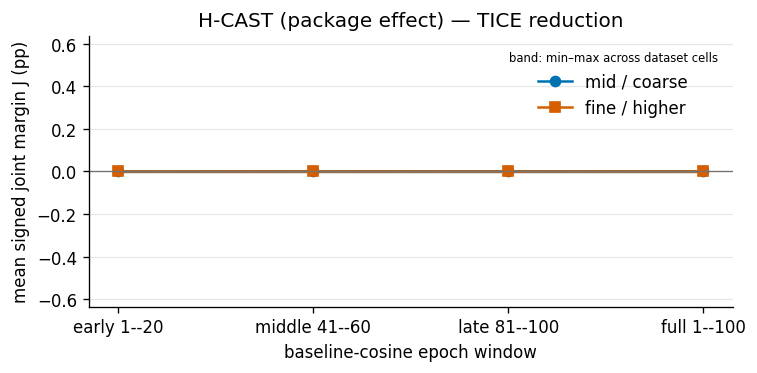

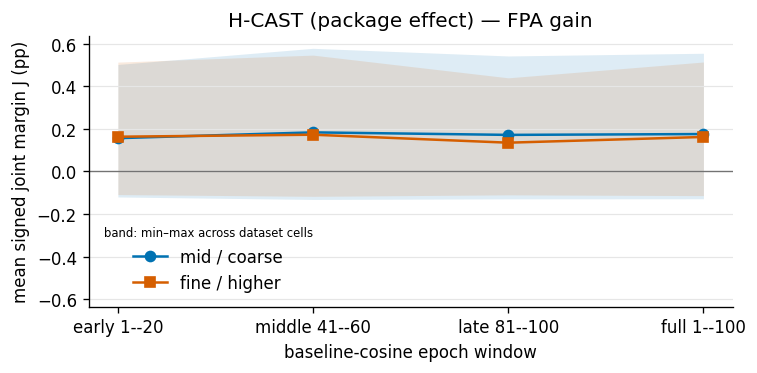

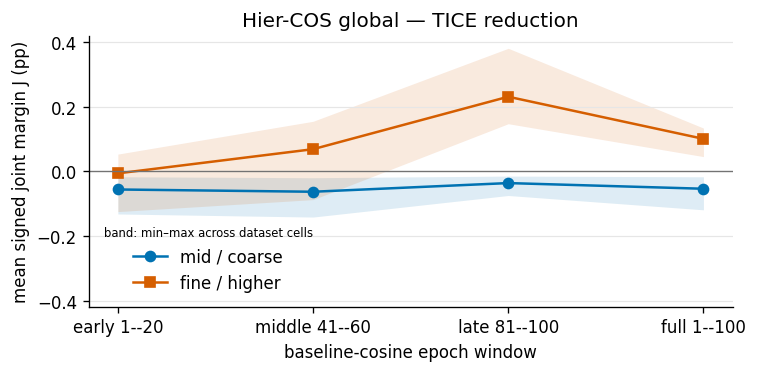

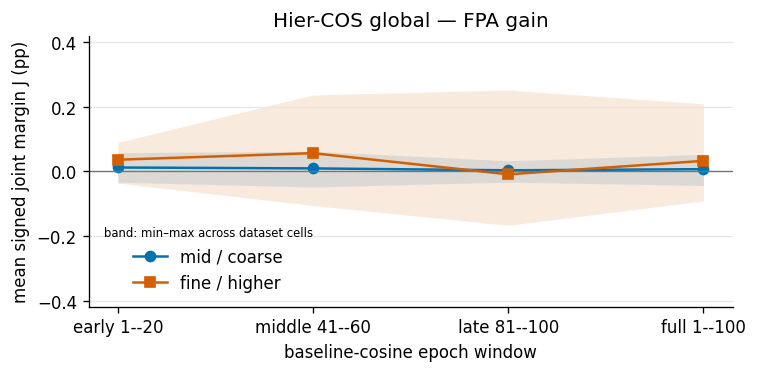

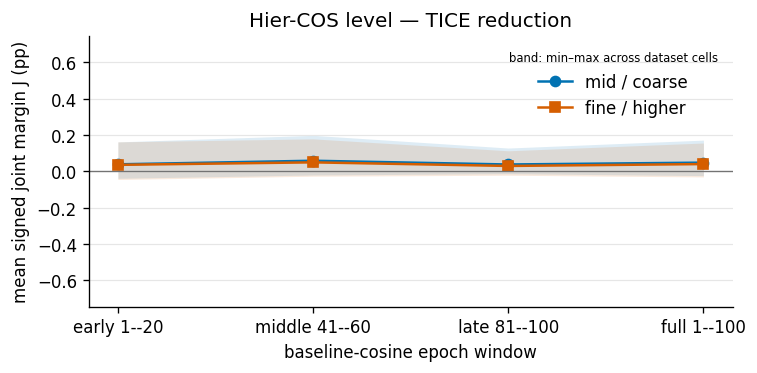

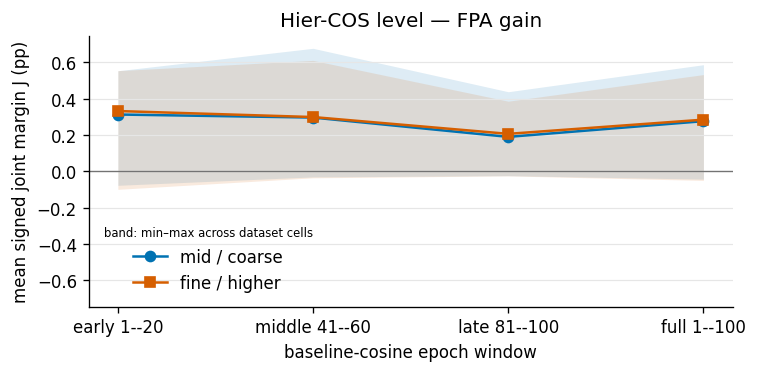

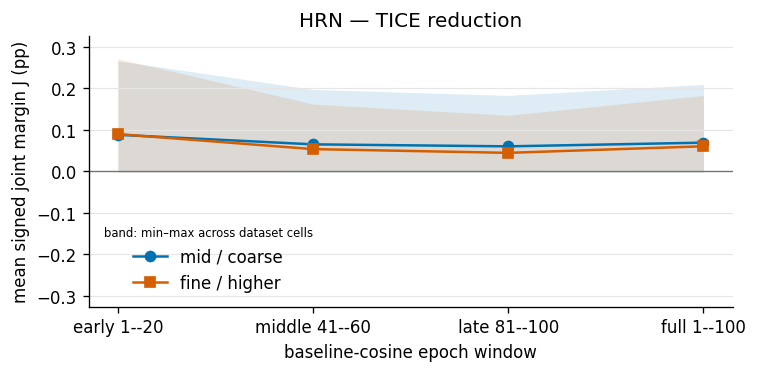

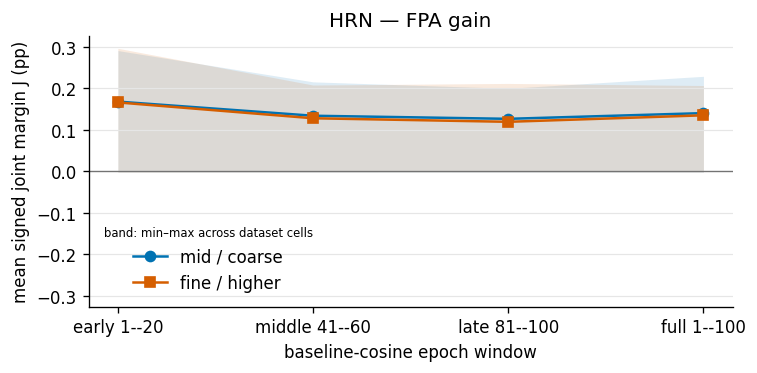

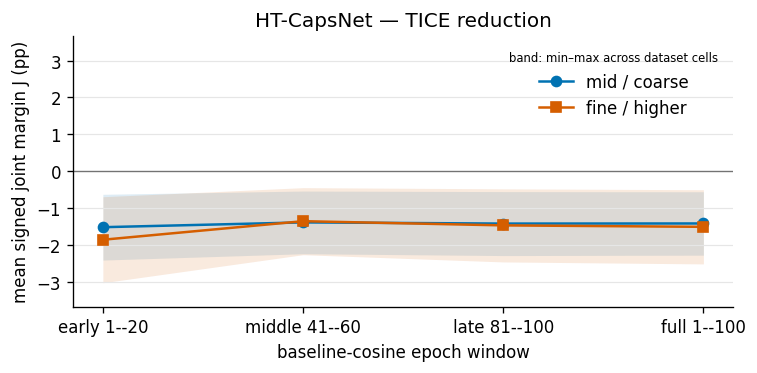

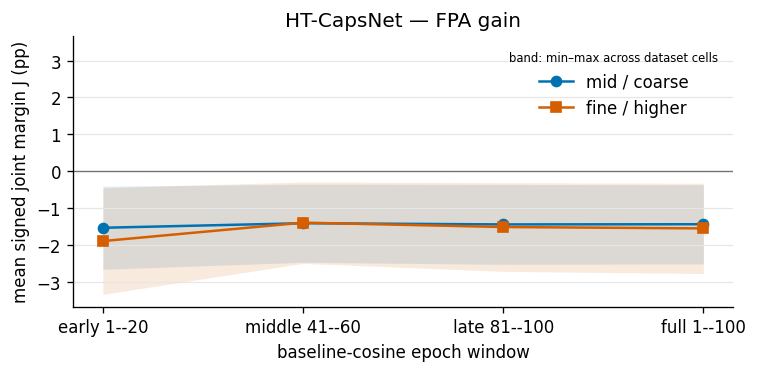

In [5]:
windows = [
    ('early 1--20', (1, 20)),
    ('middle 41--60', (41, 60)),
    ('late 81--100', (81, 100)),
    ('full 1--100', (1, 100)),
]
window_margins = window_joint_margins(
    OUTPUTS_ROOT, RUN_SPECS, windows,
    decoder=DECODER, readout=READOUT, subspace_score_space=SUBSPACE_SCORE_SPACE,
)
sensitivity_view = (
    window_margins
    .groupby(['substrate', 'comparison_scope', 'window', 'stage', 'response'], sort=False)
    .agg(
        n_cells=('joint_margin', 'size'),
        mean_joint_margin=('joint_margin', 'mean'),
        min_joint_margin=('joint_margin', 'min'),
        max_joint_margin=('joint_margin', 'max'),
    )
    .reset_index()
)
sensitivity_compact = sensitivity_view.pivot(
    index=['substrate', 'comparison_scope', 'window', 'stage', 'n_cells'],
    columns='response',
    values='mean_joint_margin',
).reset_index()
sensitivity_compact.columns = [
    column if isinstance(column, str) else ' | '.join(part for part in column if part)
    for column in sensitivity_compact.columns
]
response_columns = [column for column in sensitivity_compact.columns if column.endswith('(pp)')]
display(
    sensitivity_compact.style
    .format({column: '{:+.3f}' for column in response_columns})
    .map(shade_margin, subset=response_columns)
    .hide(axis='index')
)

window_order = [label for label, _ in windows]
window_stage_style = {
    'mid / coarse': {'color': '#0072B2', 'marker': 'o'},
    'fine / higher': {'color': '#D55E00', 'marker': 's'},
}
window_outcomes = {label: outcome_labels[label] for label in JOINT_RESPONSES}
for substrate in substrate_order(sensitivity_view):
    substrate_rows = sensitivity_view[sensitivity_view['substrate'] == substrate]
    margin_limit = 1.1 * max(
        substrate_rows['max_joint_margin'].max(),
        -substrate_rows['min_joint_margin'].min(),
        1e-3,
    )
    for response, response_label in window_outcomes.items():
        plot_rows = substrate_rows[substrate_rows['response'] == response]
        figure, axis = plt.subplots(figsize=(6.2, 3.0), constrained_layout=True)
        plotted_margins = {}
        for stage, style in window_stage_style.items():
            stage_rows = plot_rows[plot_rows['stage'] == stage].set_index('window').loc[window_order]
            plotted_margins[stage] = stage_rows['mean_joint_margin'].to_numpy()
            axis.fill_between(
                window_order, stage_rows['min_joint_margin'], stage_rows['max_joint_margin'],
                color=style['color'], alpha=0.13, linewidth=0,
            )
            axis.plot(
                window_order, stage_rows['mean_joint_margin'],
                color=style['color'], marker=style['marker'], label=stage,
            )
        if np.allclose(plotted_margins['mid / coarse'], plotted_margins['fine / higher']):
            axis.text(0.02, 0.94, 'The two stages overlap exactly', transform=axis.transAxes, va='top', fontsize=8)
        axis.axhline(0, color='0.45', linewidth=0.8)
        axis.set_ylim(-margin_limit, margin_limit)
        axis.set_ylabel('mean signed joint margin J (pp)')
        axis.set_xlabel('baseline-cosine epoch window')
        axis.set_title(f'{substrate}{scope_suffix(substrate)} — {response_label}')
        axis.grid(axis='y', color='0.9', linewidth=0.7)
        axis.legend(frameon=False, title='band: min–max across dataset cells', title_fontsize=7)
        plt.show()


## Question 2: what does projection do to the gradient geometry?

Question 1 uses the baseline cosine alone, because that is the only one of these quantities available before deciding whether to train with lex. This section looks inside the lex run, where three states can be compared at every epoch.

- **baseline**: the cosine in the paired no-lex run, same seed and schedule. This is the Question 1 predictor, shown here as the reference trajectory.
- **lex pre-projection**: the same cosine measured in the lex run immediately before the operator fires. It is not a second predictor. Projection has been changing the weights since the second step, so this quantity is caused by the intervention rather than preceding it. What it does measure is the **dose**: the component the operator is about to delete.
- **lex post-projection**: the same cosine immediately after. It is zero by construction, because projection subtracts exactly the component lying along the higher-priority direction, so its role is to verify the operator rather than to measure anything about the model.

Plotting all three per epoch replaces the earlier summary tables. It shows whether the dose persists or decays over training, and how far the lex trajectory's geometry departs from the baseline's. That gap is the path divergence, summarised separately below.

The two arms are compared at equal step count, not at equal loss. They share seed and schedule, so the pairing is fair, but by late training the two runs sit at different points in optimisation and the cosine is a property of where each run ended up.

For H-CAST a third row shows the `p12` block, the parameters reached by the coarse and middle objectives but not by the fine one. On Hier-COS, HRN and HT-CapsNet that block is empty and the logger writes a constant zero rather than a measured cosine, so the row is omitted for them.

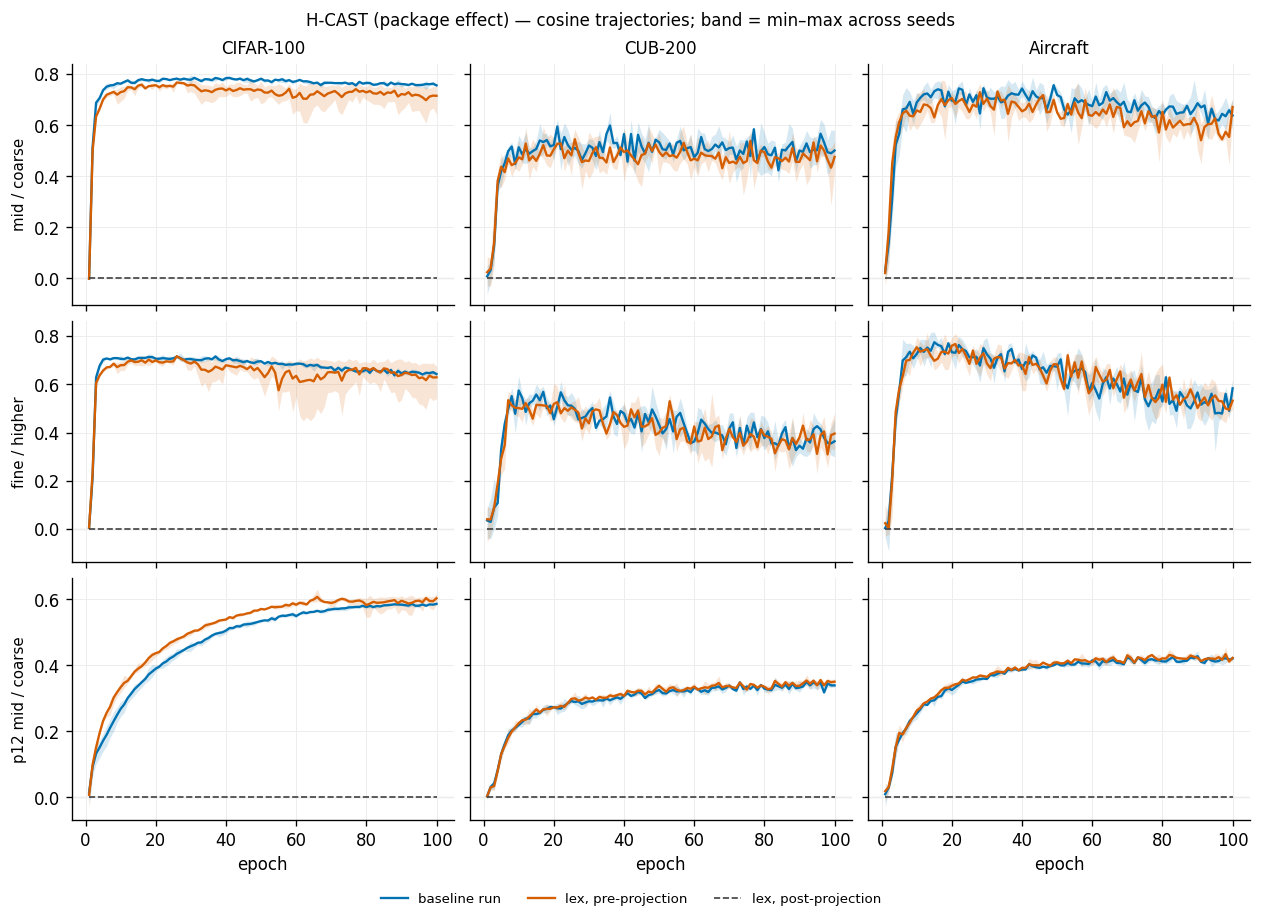

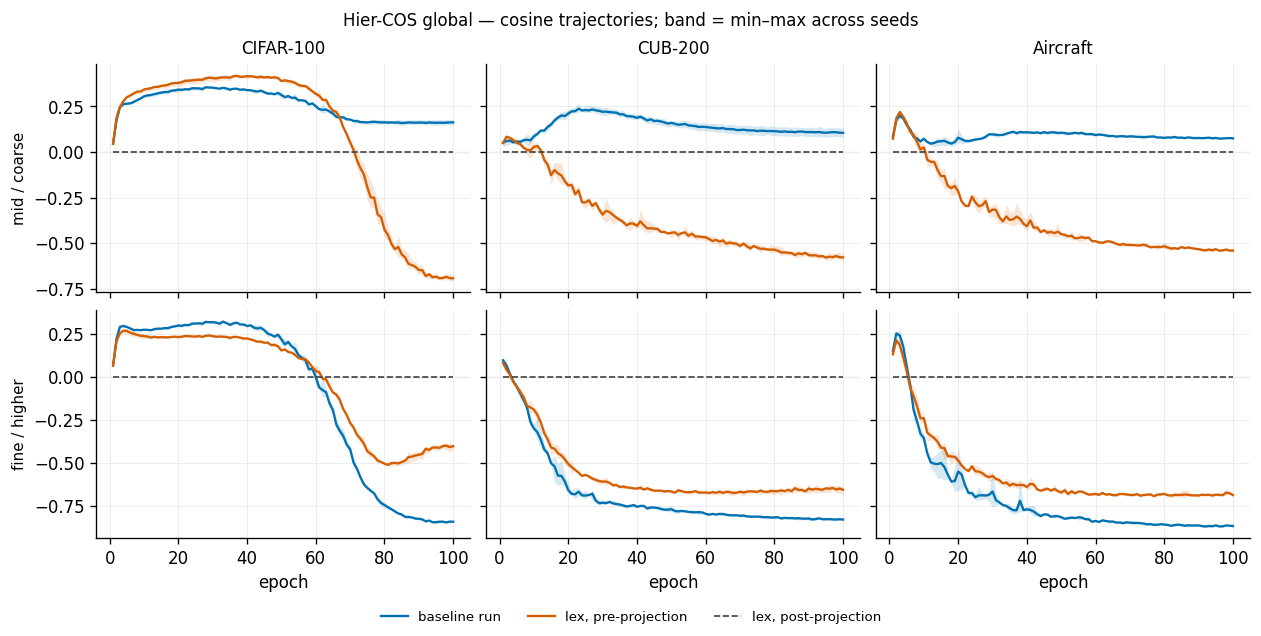

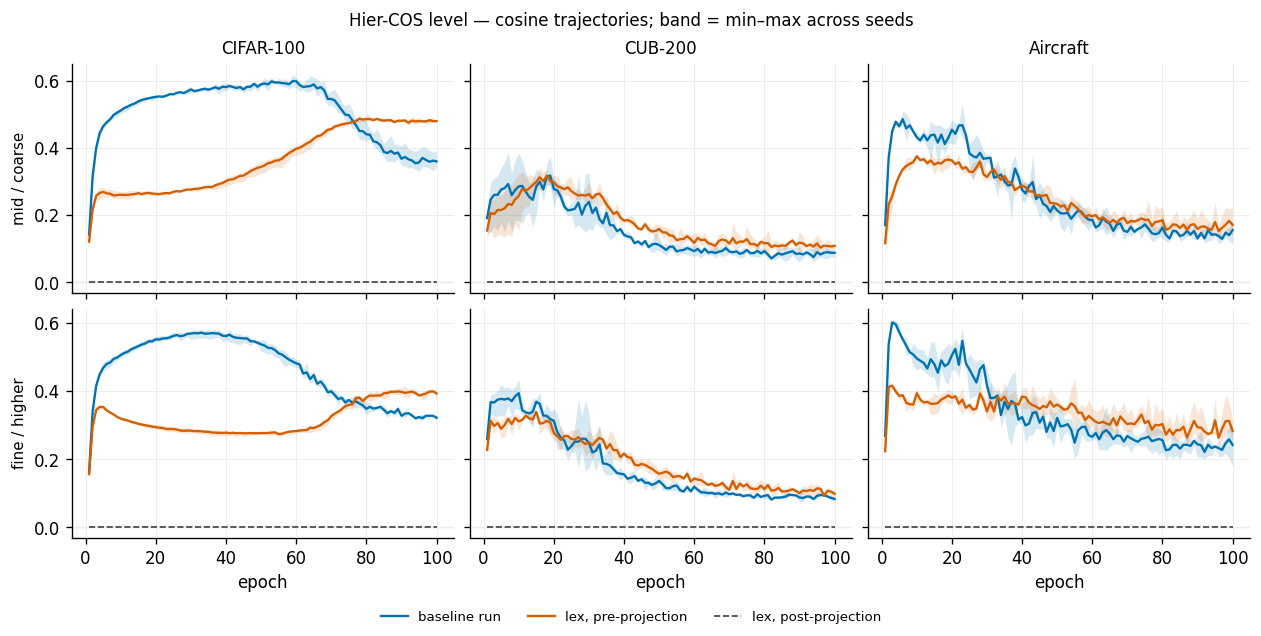

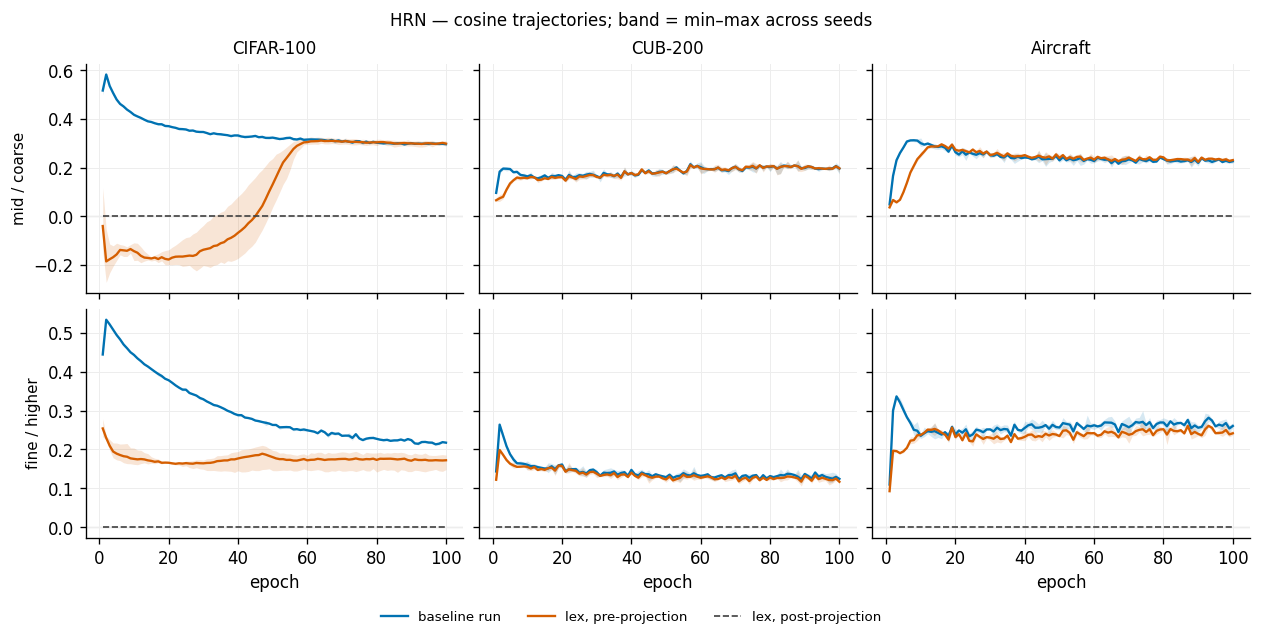

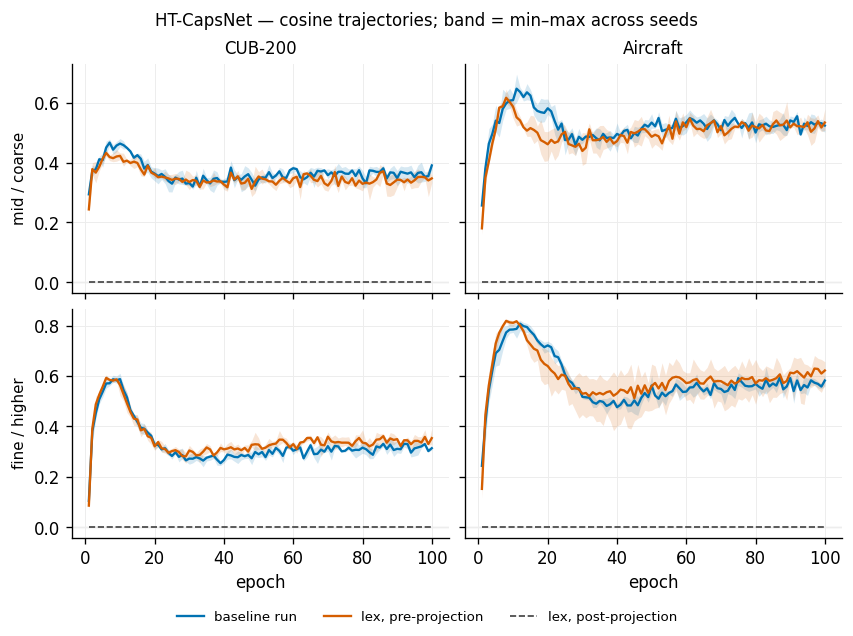

In [6]:
trajectory_df = cosine_trajectories(OUTPUTS_ROOT, RUN_SPECS, TRAJECTORY_RANGE)

# Some run logs stop early even when the run finished, which would put a step in
# the seed-averaged curve. Keep only epochs covered by every seed of a cell.
seed_counts = (
    trajectory_df.groupby(['cell_id', 'stage', 'epoch'])['seed'].nunique()
    .rename('n_seeds').reset_index()
)
expected_seeds = seed_counts.groupby(['cell_id', 'stage'])['n_seeds'].transform('max')
dropped = seed_counts[seed_counts['n_seeds'] < expected_seeds]
if not dropped.empty:
    print(f'Dropping {len(dropped)} epoch points not covered by every seed (truncated run logs).')
    trajectory_df = trajectory_df.merge(
        seed_counts[seed_counts['n_seeds'] == expected_seeds][['cell_id', 'stage', 'epoch']],
        on=['cell_id', 'stage', 'epoch'],
    )

curves = trajectory_df.groupby(['substrate', 'dataset', 'stage', 'epoch']).agg(
    baseline_mean=('baseline_cos', 'mean'),
    baseline_min=('baseline_cos', 'min'),
    baseline_max=('baseline_cos', 'max'),
    lex_pre_mean=('lex_pre_cos', 'mean'),
    lex_pre_min=('lex_pre_cos', 'min'),
    lex_pre_max=('lex_pre_cos', 'max'),
    lex_post_mean=('lex_post_cos', 'mean'),
).reset_index()

arm_style = {
    'baseline': {'color': '#0072B2', 'label': 'baseline run'},
    'lex_pre': {'color': '#D55E00', 'label': 'lex, pre-projection'},
}
dataset_order = sorted(DATASET_RANK, key=DATASET_RANK.get)
stage_order = ['mid / coarse', 'fine / higher', 'p12 mid / coarse']

for substrate in substrate_order(curves):
    substrate_curves = curves[curves['substrate'] == substrate]
    stages = [stage for stage in stage_order if stage in set(substrate_curves['stage'])]
    # Only the datasets with a completed pair get a column, so a substrate with
    # partial coverage is drawn narrower instead of showing empty panels.
    datasets = [dataset for dataset in dataset_order if dataset in set(substrate_curves['dataset'])]
    figure, axes = plt.subplots(
        len(stages), len(datasets),
        figsize=(3.4 * len(datasets) + 0.2, 2.35 * len(stages) + 0.5),
        sharex=True, sharey='row', squeeze=False, constrained_layout=True,
    )
    for row_index, stage in enumerate(stages):
        for column_index, dataset in enumerate(datasets):
            axis = axes[row_index][column_index]
            panel = substrate_curves[
                (substrate_curves['stage'] == stage)
                & (substrate_curves['dataset'] == dataset)
            ].sort_values('epoch')
            axis.axhline(0, color='0.7', linewidth=0.7, zorder=0)
            for prefix, style in arm_style.items():
                axis.fill_between(
                    panel['epoch'], panel[f'{prefix}_min'], panel[f'{prefix}_max'],
                    color=style['color'], alpha=0.16, linewidth=0, zorder=2,
                )
                axis.plot(
                    panel['epoch'], panel[f'{prefix}_mean'],
                    color=style['color'], linewidth=1.4, label=style['label'], zorder=3,
                )
            axis.plot(
                panel['epoch'], panel['lex_post_mean'],
                color='0.25', linewidth=1.0, linestyle='--',
                label='lex, post-projection', zorder=4,
            )
            axis.grid(color='0.93', linewidth=0.6, zorder=0)
            if row_index == 0:
                axis.set_title(dataset, fontsize=10)
            if column_index == 0:
                axis.set_ylabel(stage, fontsize=9)
            if row_index == len(stages) - 1:
                axis.set_xlabel('epoch')
    handles, labels = axes[0][0].get_legend_handles_labels()
    figure.legend(handles, labels, loc='outside lower center', ncols=3, frameon=False, fontsize=8)
    figure.suptitle(
        f'{substrate}{scope_suffix(substrate)} — cosine trajectories; band = min–max across seeds',
        fontsize=10,
    )
    plt.show()


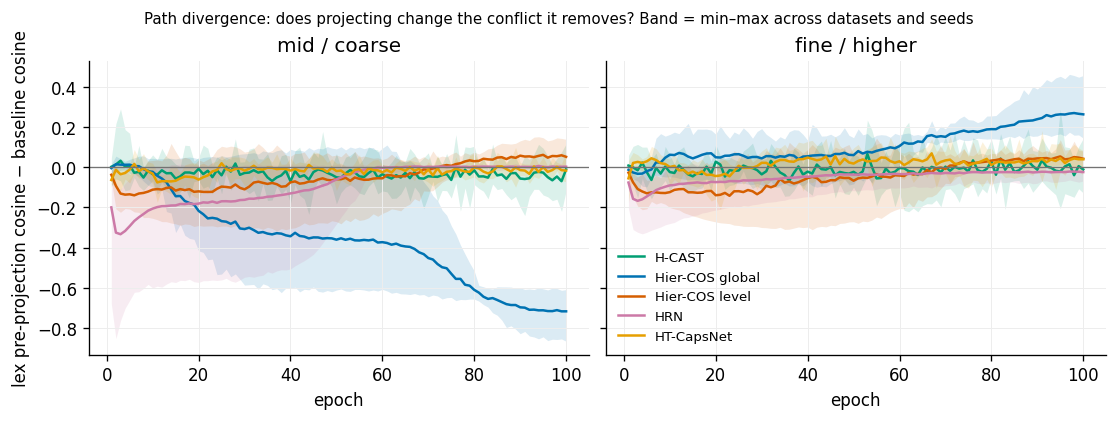

Operator validity, over every cell, stage, seed and epoch:
  maximum absolute post-projection cosine: 4.156e-07
  minimum projection-applied fraction: 1.000

Late window 81--100, seed and dataset means:
  H-CAST, mid / coarse: baseline +0.638, lex pre +0.597, divergence -0.042
  H-CAST, fine / higher: baseline +0.517, lex pre +0.516, divergence -0.001
  H-CAST, p12 mid / coarse: baseline +0.446, lex pre +0.453, divergence +0.008
  Hier-COS global, mid / coarse: baseline +0.116, lex pre -0.574, divergence -0.690
  Hier-COS global, fine / higher: baseline -0.836, lex pre -0.596, divergence +0.240
  Hier-COS level, mid / coarse: baseline +0.203, lex pre +0.253, divergence +0.050
  Hier-COS level, fine / higher: baseline +0.221, lex pre +0.263, divergence +0.042
  HRN, mid / coarse: baseline +0.242, lex pre +0.244, divergence +0.002
  HRN, fine / higher: baseline +0.205, lex pre +0.182, divergence -0.024
  HT-CapsNet, mid / coarse: baseline +0.445, lex pre +0.433, divergence -0.012
  HT-Ca

In [7]:
trajectory_df['path_divergence'] = trajectory_df['lex_pre_cos'] - trajectory_df['baseline_cos']
divergence_curves = trajectory_df.groupby(['substrate', 'stage', 'epoch']).agg(
    mean_divergence=('path_divergence', 'mean'),
    min_divergence=('path_divergence', 'min'),
    max_divergence=('path_divergence', 'max'),
).reset_index()

shared_stages = ['mid / coarse', 'fine / higher']
divergence_style = {
    substrate: SUBSTRATE_STYLES[substrate]
    for substrate in substrate_order(divergence_curves)
}
figure, axes = plt.subplots(1, 2, figsize=(9.2, 3.4), sharex=True, sharey=True, constrained_layout=True)
for axis, stage in zip(axes, shared_stages):
    for substrate, style in divergence_style.items():
        panel = divergence_curves[
            (divergence_curves['substrate'] == substrate)
            & (divergence_curves['stage'] == stage)
        ].sort_values('epoch')
        axis.fill_between(
            panel['epoch'], panel['min_divergence'], panel['max_divergence'],
            color=style['color'], alpha=0.14, linewidth=0,
        )
        axis.plot(panel['epoch'], panel['mean_divergence'], color=style['color'],
                  linewidth=1.5, label=substrate)
    axis.axhline(0, color='0.45', linewidth=0.8)
    axis.set_title(stage)
    axis.set_xlabel('epoch')
    axis.grid(color='0.93', linewidth=0.6)
axes[0].set_ylabel('lex pre-projection cosine − baseline cosine')
axes[1].legend(frameon=False, fontsize=8)
figure.suptitle(
    'Path divergence: does projecting change the conflict it removes? '
    'Band = min–max across datasets and seeds',
    fontsize=9,
)
plt.show()

print('Operator validity, over every cell, stage, seed and epoch:')
print(f'  maximum absolute post-projection cosine: {trajectory_df["lex_post_cos"].abs().max():.3e}')
print(f'  minimum projection-applied fraction: {trajectory_df["projection_applied"].min():.3f}')

late_rows = trajectory_df[trajectory_df['epoch'].between(*EPOCH_WINDOW)]
print(f'\nLate window {EPOCH_WINDOW[0]}--{EPOCH_WINDOW[1]}, seed and dataset means:')
for (substrate, stage), rows in late_rows.groupby(['substrate', 'stage'], sort=False):
    print(
        f'  {substrate}, {stage}: baseline {rows["baseline_cos"].mean():+.3f}, '
        f'lex pre {rows["lex_pre_cos"].mean():+.3f}, '
        f'divergence {rows["path_divergence"].mean():+.3f}'
    )


## Evidence-level interpretation

The cell below prints the signed joint margins directly from the current files. `J` carries both sign and magnitude: it is positive only when conflict accompanies improvement or alignment accompanies deterioration, and its size reflects how far both the cosine and the performance change are from zero. The per-cell range is printed alongside each mean, together with the number of cells behind it, because a mean over dataset cells can hide a sign disagreement and because coverage is uneven across substrates. TICE and FPA remain separate, as do Hier-COS global and level softmax.

In [8]:
print('Signed joint margin J = -baseline cosine × performance improvement; positive supports the hypothesis')
for outcome in outcome_specs:
    print(f'\n{outcome}:')
    for substrate in group_order:
        rows = joint_check[(joint_check['outcome'] == outcome) & (joint_check['model'] == substrate)]
        parts = [
            f'{row.cosine}: mean J = {row["mean J"]:+.3f} '
            f'over {row["evaluated cells"]} cells '
            f'[{row["min J"]:+.3f}, {row["max J"]:+.3f}]'
            for _, row in rows.iterrows()
        ]
        print(f'  {substrate}: ' + '; '.join(parts))

print('\nLate-window signed joint margins:')
late_rows = sensitivity_view[sensitivity_view['window'] == 'late 81--100']
for _, row in late_rows.iterrows():
    print(
        f'  {row.substrate}, {row.stage}, {row.response}: '
        f'mean J = {row.mean_joint_margin:+.3f} over {row.n_cells} cells '
        f'[{row.min_joint_margin:+.3f}, {row.max_joint_margin:+.3f}]'
    )

resolved_audit = audit_df[audit_df['n'] > 0]
package_cells = resolved_audit[~resolved_audit['config_matched']]
if not package_cells.empty:
    print('\nShown as package effects, because the resolved baseline and lex configs are not projection-only matched:')
    for _, row in package_cells.iterrows():
        print(f'  {row.substrate}, {row.dataset}: {row.baseline_run} vs {row.lex_run}')

thin_cells = resolved_audit[resolved_audit['n'] < resolved_audit['n'].max()]
if not thin_cells.empty:
    print('\nCells resolved on fewer paired seeds than the best-covered cell; their deltas carry no seed spread:')
    for _, row in thin_cells.iterrows():
        print(f'  {row.substrate}, {row.dataset}: n = {row.n}')

missing_cells = audit_df[audit_df['n'] == 0]
if not missing_cells.empty:
    print('\nCells with no completed paired seeds, absent from every table and figure above:')
    for _, row in missing_cells.iterrows():
        print(f'  {row.substrate}, {row.dataset}: {row.lex_run}')

print('\nThe within-lex pre/post projection check is valid for every substrate and both shared cosine stages.')


Signed joint margin J = -baseline cosine × performance improvement; positive supports the hypothesis

TICE reduction:
  H-CAST: mid / coarse: mean J = -0.000 over 3 cells [-0.010, +0.009]; fine / higher: mean J = -0.001 over 3 cells [-0.009, +0.006]
  Hier-COS global: mid / coarse: mean J = -0.036 over 3 cells [-0.075, -0.015]; fine / higher: mean J = +0.230 over 3 cells [+0.147, +0.380]
  Hier-COS level: mid / coarse: mean J = +0.038 over 3 cells [-0.013, +0.128]; fine / higher: mean J = +0.030 over 3 cells [-0.021, +0.113]
  HRN: mid / coarse: mean J = +0.060 over 3 cells [-0.002, +0.183]; fine / higher: mean J = +0.045 over 3 cells [-0.002, +0.135]
  HT-CapsNet: mid / coarse: mean J = -1.415 over 2 cells [-2.281, -0.548]; fine / higher: mean J = -1.463 over 2 cells [-2.453, -0.474]

FPA gain:
  H-CAST: mid / coarse: mean J = +0.171 over 3 cells [-0.129, +0.542]; fine / higher: mean J = +0.135 over 3 cells [-0.110, +0.439]
  Hier-COS global: mid / coarse: mean J = +0.003 over 3 cells